## What I found in this data

This dataset has daily prices for 5 different energy commodities (Crude Oil,
Brent Crude Oil, Natural Gas, Heating Oil, RBOB Gasoline) from the year 2000
to 2024. In total there are about 28,000 rows.

**Data quality:**
- No missing values and no duplicate rows, so the data was already pretty clean.
- I converted the date column from text into a real date format so I can do
  time-based analysis later (like sorting and plotting by date).

**Interesting things I found:**
- On 20-21 April 2020, Crude Oil prices actually went negative.
  At first I thought this was an error in the data, but after checking, this
  was a real event: during COVID lockdowns, demand for oil dropped so much
  that storage was running out, so traders had to pay buyers to take the oil
  off their hands instead of dealing with physical delivery.
- Crude Oil and Brent Crude Oil move almost the same way over time, which
  makes sense because they are both major oil price benchmarks.
- Natural Gas had a big price spike in 2022, most likely connected to the
  energy crisis caused by the Russia-Ukraine war.
- Crude Oil and Brent Crude are priced much higher (in the hundreds of
  dollars) compared to Natural Gas, Heating Oil and RBOB Gasoline (priced in
  single digits), so I had to plot them separately to actually see the trends
  clearly.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('../data/raw/all_fuels_data.csv')

# Quick first look
print(df.shape)
df.head()

(28075, 8)


,ticker,commodity,date,open,high,low,close,volume
0,CL=F,Crude Oil,2000-08-23,31.950001,32.799999,31.950001,32.049999,79385
1,CL=F,Crude Oil,2000-08-24,31.900000,32.240002,31.400000,31.629999,72978
2,CL=F,Crude Oil,2000-08-25,31.700001,32.099998,31.320000,32.049999,44601
3,CL=F,Crude Oil,2000-08-28,32.040001,32.919998,31.860001,32.869999,46770
4,CL=F,Crude Oil,2000-08-29,32.820000,33.029999,32.560001,32.720001,49131


In [2]:
# Data types and missing values
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())

# Convert date column to actual datetime (currently it's just text)
df['date'] = pd.to_datetime(df['date'])

# Check date range and row count per commodity
print("\nDate range and count per commodity:")
print(df.groupby('commodity')['date'].agg(['min', 'max', 'count']))

ticker           str
commodity        str
date             str
open         float64
high         float64
low          float64
close        float64
volume         int64
dtype: object

Missing values per column:
ticker       0
commodity    0
date         0
open         0
high         0
low          0
close        0
volume       0
dtype: int64

Date range and count per commodity:
                       min        max  count
commodity                                   
Brent Crude Oil 2007-07-30 2024-06-24   4196
Crude Oil       2000-08-23 2024-06-24   5984
Heating Oil     2000-09-01 2024-06-24   5977
Natural Gas     2000-08-30 2024-06-24   5980
RBOB Gasoline   2000-11-01 2024-06-24   5938


In [3]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Basic sanity checks on price/volume columns
print("\nSummary statistics:")
print(df[['open', 'high', 'low', 'close', 'volume']].describe())

# Check for any negative or zero prices (shouldn't exist for real commodities)
print("\nRows with non-positive prices:")
print(df[(df['open'] <= 0) | (df['close'] <= 0)])

Duplicate rows: 0

Summary statistics:
               open          high           low         close        volume
count  28075.000000  28075.000000  28075.000000  28075.000000  2.807500e+04
mean      27.288994     27.680580     26.873389     27.287224  1.059926e+05
std       36.085625     36.540236     35.599243     36.089001  1.484400e+05
min      -14.000000      0.507000    -40.320000    -37.630001  0.000000e+00
25%        2.031000      2.060550      1.998200      2.031250  2.641100e+04
50%        3.374000      3.450000      3.301000      3.375900  4.903300e+04
75%       54.895000     55.745001     53.910000     54.900000  1.147245e+05
max      146.080002    147.429993    144.270004    146.080002  2.288230e+06

Rows with non-positive prices:
     ticker  commodity       date   open   high    low      close   volume
4931   CL=F  Crude Oil 2020-04-20  17.73  17.85 -40.32 -37.630001   247947
4932   CL=F  Crude Oil 2020-04-21 -14.00  13.86 -16.74  10.010000  2288230


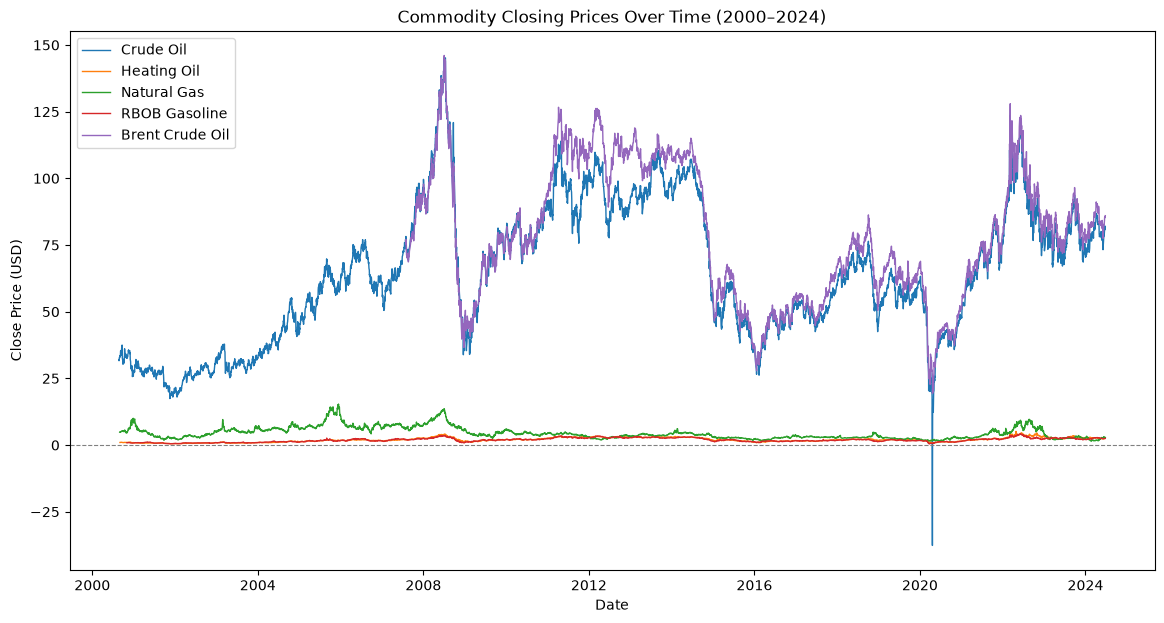

In [4]:
fig, ax = plt.subplots(figsize=(14, 7))

for commodity in df['commodity'].unique():
    subset = df[df['commodity'] == commodity]
    ax.plot(subset['date'], subset['close'], label=commodity, linewidth=1)

ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Commodity Closing Prices Over Time (2000–2024)')
ax.set_xlabel('Date')
ax.set_ylabel('Close Price (USD)')
ax.legend()
plt.show()

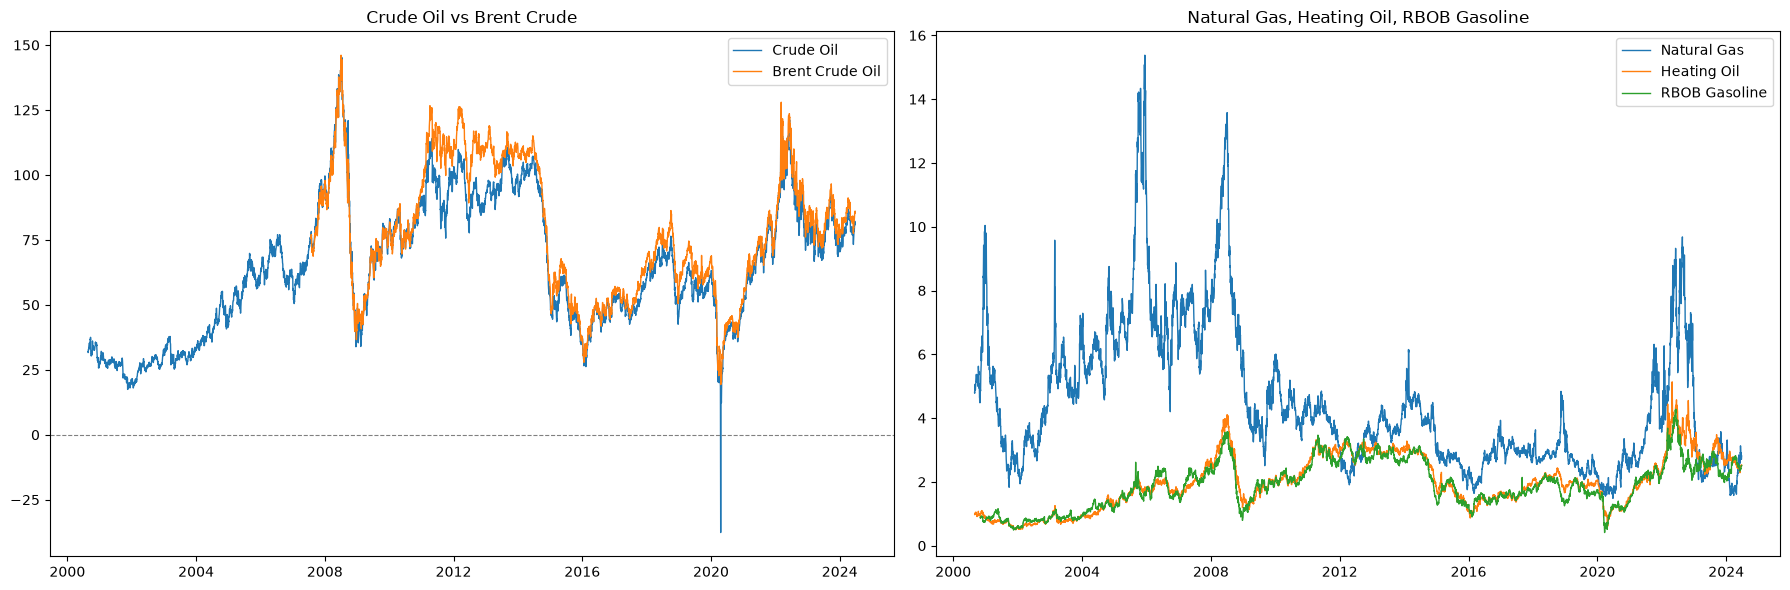

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: Crude oils (similar scale)
for commodity in ['Crude Oil', 'Brent Crude Oil']:
    subset = df[df['commodity'] == commodity]
    axes[0].plot(subset['date'], subset['close'], label=commodity, linewidth=1)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_title('Crude Oil vs Brent Crude')
axes[0].legend()

# Right: smaller-priced commodities
for commodity in ['Natural Gas', 'Heating Oil', 'RBOB Gasoline']:
    subset = df[df['commodity'] == commodity]
    axes[1].plot(subset['date'], subset['close'], label=commodity, linewidth=1)
axes[1].set_title('Natural Gas, Heating Oil, RBOB Gasoline')
axes[1].legend()

plt.tight_layout()
plt.show()

In [6]:
# Save cleaned dataset to processed folder
df.to_csv('../data/processed/all_fuels_cleaned.csv', index=False)
print("Saved cleaned dataset:", df.shape)

Saved cleaned dataset: (28075, 8)
